# Graph classification

Some dataset comes with intrinsic values that can be used as filtrations, e.g.,
graphs, medical images, molecules. Multiparameter persistence is then very well
suited to deal with all of this information **at once**. This example turns
graphs into `SimplexTreeMulti` objects (see the
[custom multi-filtration notebook](../simplex_tree_by_hand.ipynb)) and then
into [signed measures](../invariants/signed_measure.ipynb). To bring this to
light, we will consider the BZR graph dataset. It can be found
[here](https://networkrepository.com/BZR.php).

In [1]:
import multipers.data.graphs as mdg
import multipers.ml.signed_measures as mms
import networkx as nx
from random import choice
from os.path import expanduser
import numpy as np
np.random.seed(1)
dataset = "graphs/MUTAG"
path = mdg.DATASET_PATH+dataset
!ls $path ## We assume that the dataset is in this folder. You can modify the variable `mdg.DATASET_PATH` if necessary

graphs.pkl         MUTAG.csv          Mutag.graph_labels Mutag.node_labels
labels.pkl         Mutag.edges        MUTAG.hdf5         Mutag.readme
mat                Mutag.graph_idx    Mutag.link_labels


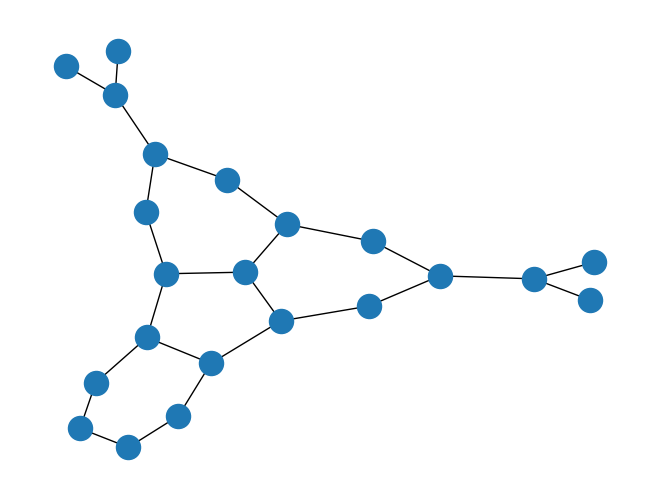

In [2]:
graphs, labels = mdg.get_graphs(dataset)
nx.draw(choice(graphs))

Graph dataset can be filtered by several filtration : node degrees, intrinsic values, ricci curvature, closeness centrality, heat kernel signature, etc.

In [3]:
# mdg.reset_graphs(dataset=dataset) # Enforce graph to be read from file

In [4]:
filtrations = ["hks_10","degree","hks_1", "cc"]
for f in filtrations:
    mdg.compute_filtration(dataset, filtration=f)
graphs, labels = mdg.get_graphs(dataset) # Retrieves these filtrations
g = graphs[0] # First graph of the dataset
g.nodes[0] # First node of the dataset, which holds several filtrations

Computing hks_10: 100%|█| 188/188 [00:00<
Computing degree: 100%|█| 188/188 [00:00<
Computing hks_1: 100%|█| 188/188 [00:00<0
Computing cc: 100%|█| 188/188 [00:00<00:0


{'cc': 0.2553191489361702,
 'degree': 0.5,
 'ricciCurvature': -0.08333333333333326,
 'fiedler': np.float64(0.0026792109689714964),
 'hks_10': np.float64(0.0696353902535798),
 'geodesic': 0,
 'hks_1': np.float64(0.4486299521593603)}

Similarly to the point clouds, we can create simplextrees, and turn them into
[signed measures](../invariants/signed_measure.ipynb).

In [5]:
simplextrees = mdg.Graph2SimplexTrees(filtrations=filtrations).fit_transform(graphs)

In [6]:
signed_measures = mms.FilteredComplex2SignedMeasure(
	degrees=[None,1], n_jobs=1, grid_strategy='exact', enforce_null_mass=True
).fit_transform(simplextrees) # None correspond to the euler characteristic, which is significantly faster to compute on graphs. 
# One may want to rescale filtrations w.r.t. each other. This can be done using the SignedMeasureFormatter class
signed_measures = mms.SignedMeasureFormatter(normalize=True, axis=0).fit_transform(signed_measures)

And finally classify these graphs using either a sliced wasserstein kernel, or a convolution.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from multipers.ml.kernels import DistanceMatrix2Kernel
from sklearn.model_selection import StratifiedKFold, cross_val_score

classifier = Pipeline([
    ("SWD",mms.SignedMeasure2SlicedWassersteinDistance(n_jobs=-1, num_directions=100)),
    ("KERNEL", DistanceMatrix2Kernel(sigma=.1)),
    ("SVM", SVC(kernel="precomputed")),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    classifier,
    signed_measures,
    labels,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
)

print("Scores:",np.asarray(scores).round(3),"\nMean±std:",np.mean(scores).round(3),"±",np.std(scores).round(3),sep="")

Scores:[0.789 0.632 0.763 0.784 0.784]
Mean±std:0.75±0.06
